# Imports

Treasury: DGS10
S&P500: SP500
Bitcoin: Close

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import uniform_filter1d

from statsmodels.tsa.stattools import adfuller, acf, pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Optional if installed
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except Exception:
    ARCH_AVAILABLE = False

# Optional for deep models
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import TCN, Autoformer
    from neuralforecast.losses.pytorch import MAE
    NF_AVAILABLE = True
except Exception:
    NF_AVAILABLE = False

2026-04-24 14:45:58,732	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-24 14:45:58,878	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# ============================================================
# 1. Data loading
# ============================================================
def load_data(name, start_date='2021-01-01'):
    if name == "BTC":
        bitcoin_close = "bitcoin_close.csv"
        data = pd.read_csv(f'./data/processed/{bitcoin_close}', parse_dates=["date"])
        data["btc_close"] = pd.to_numeric(data["btc_close"], errors="coerce")
        data = data.dropna(subset=["date", "btc_close"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['btc_close'].values, index=data['date'])

    elif name == "SP500":
        SP500 = "sp500_cleaned.csv"
        data = pd.read_csv(f'./data/processed/{SP500}', parse_dates=["date"])
        data["sp500"] = pd.to_numeric(data["sp500"], errors="coerce")
        data = data.dropna(subset=["date", "sp500"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['sp500'].values, index=data['date'])

    elif name == "FRED":
        FRED = "treasury_dgs10.csv"
        data = pd.read_csv(f'./data/processed/{FRED}', parse_dates=["date"])
        data["dgs10"] = pd.to_numeric(data["dgs10"], errors="coerce")
        data = data.dropna(subset=["date", "dgs10"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['dgs10'].values, index=data['date'])

    else:
        raise ValueError("Unsupported dataset name. Use 'BTC', 'SP500', or 'FRED'.")

    return data


# ============================================================
# 2. Helper functions
# ============================================================
def train_test_split_ts(series, test_size=0.2):
    n = len(series)
    split_idx = int(n * (1 - test_size))
    train = series.iloc[:split_idx].copy()
    test = series.iloc[split_idx:].copy()
    return train, test

def accuracy_metrics(y_true, y_pred, label="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    bias = np.mean(y_pred - y_true)
    pm = np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)
    
    print(f"{label} MSE:   {mse:.4f}")
    print(f"{label} RMSE:  {rmse:.4f}")
    print(f"{label} MAE:   {mae:.4f}")
    print(f"{label} MAPE:  {mape:.4f}%")
    print(f"{label} Bias:  {bias:.4f}")
    print(f"{label} PM:    {pm:.4f}")
    print()

    return {
        "Model": label,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "Bias": bias,
        "PM": pm
    }

def rolling_mean_vol(series, window=30):
    values = np.asarray(series, dtype=float)

    roll_mean = uniform_filter1d(values, size=window, mode="nearest")

    sq_mean = uniform_filter1d(values**2, size=window, mode="nearest")
    roll_var = sq_mean - roll_mean**2
    roll_var = np.maximum(roll_var, 0)
    roll_std = np.sqrt(roll_var)

    out = pd.DataFrame(index=series.index)
    out["value"] = series
    out["roll_mean"] = roll_mean
    out["roll_std"] = roll_std
    return out

def horizonwise_errors(y_true_mat, y_pred_mat):
    """
    y_true_mat, y_pred_mat: arrays shape (n_windows, h)
    """
    h = y_true_mat.shape[1]
    rows = []
    for j in range(h):
        err = y_pred_mat[:, j] - y_true_mat[:, j]
        rows.append({
            "horizon": j + 1,
            "bias": np.mean(err),
            "var_error": np.var(err),
            "mae": np.mean(np.abs(err)),
            "rmse": np.sqrt(np.mean(err ** 2))
        })
    return pd.DataFrame(rows)

# ============================================================
# Choose differencing systematically
# ============================================================

def select_d_by_adf(series, max_d=2, alpha=0.05):
    results = []

    for d in range(max_d + 1):
        if d == 0:
            s = series.dropna()
        else:
            s = series.copy()
            for _ in range(d):
                s = s.diff()
            s = s.dropna()

        adf_res = adfuller(s, autolag="AIC")
        pval = adf_res[1]

        results.append({
            "d": d,
            "adf_stat": adf_res[0],
            "pvalue": pval
        })

        if pval < alpha:
            print(f"Selected d = {d} based on ADF p-value = {pval:.4f}")
            return d, pd.DataFrame(results)

    print(f"No differencing level up to max_d={max_d} passed ADF at alpha={alpha}. Using d={max_d}.")
    return max_d, pd.DataFrame(results)

# ============================================================
# ARIMA Model Estimation
# ============================================================

def fit_arima(train_series, order):
    
    model = ARIMA(train_series, order=order)
    result = model.fit()
    
    print(result.summary())
    
    return result

# ============================================================
# SARIMA Model Estimation
# ============================================================

def fit_sarima(train_series, order, seasonal_order):
    
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit()
    
    print(result.summary())
    
    return result

# ============================================================
# Forecast Function
# ============================================================

def forecast_model(model_fit, train_series, test_series, alpha=0.05):
    
    forecast_res = model_fit.get_forecast(steps=len(test_series))
    forecast = pd.Series(
        forecast_res.predicted_mean.to_numpy(),
        index=test_series.index
    )
    # forecast = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int(alpha=alpha)
    conf_int = pd.DataFrame(
        conf_int.to_numpy(),
        index=test_series.index,
        columns=["lower", "upper"]
    )
    
    # forecast = pd.Series(forecast, index=test_series.index)
    # conf_int.index = test_series.index
    
    accuracy_metrics(test_series, forecast, label="Forecast")
    
    plt.figure(figsize=(12,4))
    plt.plot(train_series, label="Train")
    plt.plot(test_series, label="Test")
    plt.plot(forecast, label="Forecast", color="C2")
    
    plt.fill_between(
        test_series.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        color="C2",
        alpha=0.2,
        label=f"{int((1-alpha)*100)}% Confidence Interval"
    )
    
    plt.title("Forecast vs True Values")
    plt.legend()
    plt.show()
    
    return forecast

# ============================================================
# Residual Diagnostics
# ============================================================

def residual_diagnostics(model_fit):

    resid = model_fit.resid
    
    plt.figure(figsize=(12,4))
    plt.plot(resid)
    plt.title("Model Residuals")
    plt.show()
    
    
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    plot_acf(resid, lags=40, ax=axes[0])
    plot_pacf(resid, lags=40, ax=axes[1])
    axes[0].set_title("ACF of Residuals")
    axes[1].set_title("PACF of Residuals")
    plt.show()
    
    
    lb = acorr_ljungbox(resid, lags=[10,20,40], return_df=True)
    
    print("\nLjung-Box Test on Residuals:")
    print(lb)

In [4]:
DATA_SET = "BTC"  # "BTC", "SP500", or "FRED"
df = load_data(DATA_SET)
df_orig = df.copy()  # Keep original for later use
scaler = StandardScaler()
df_scaled = pd.Series(
    scaler.fit_transform(df.values.reshape(-1,1)).flatten(),
    index=df.index
)

# EDA

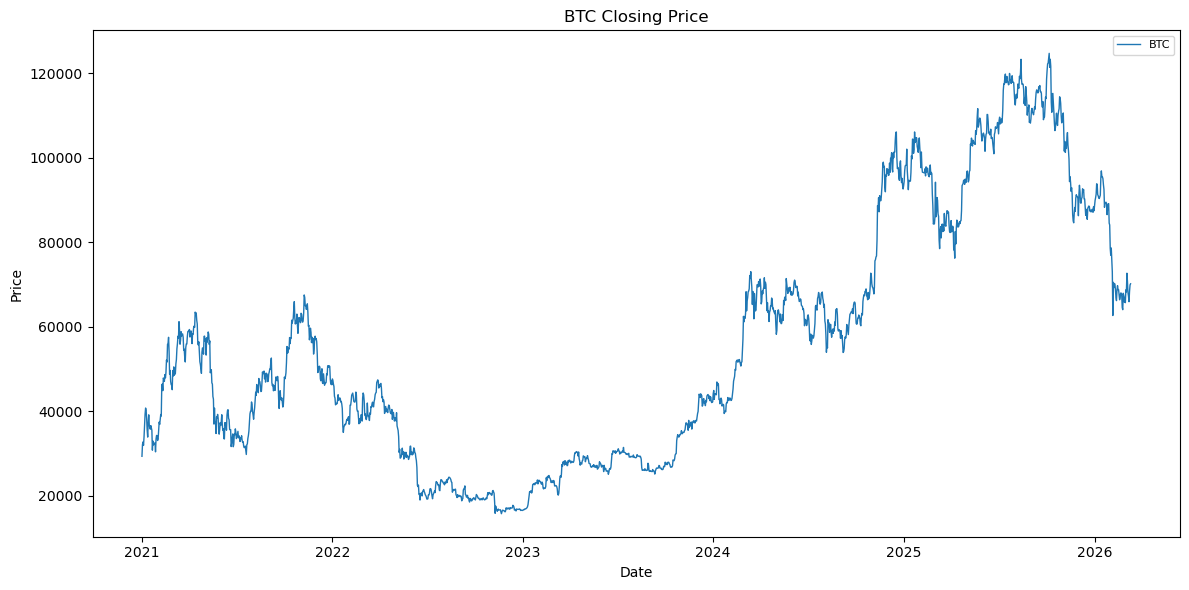

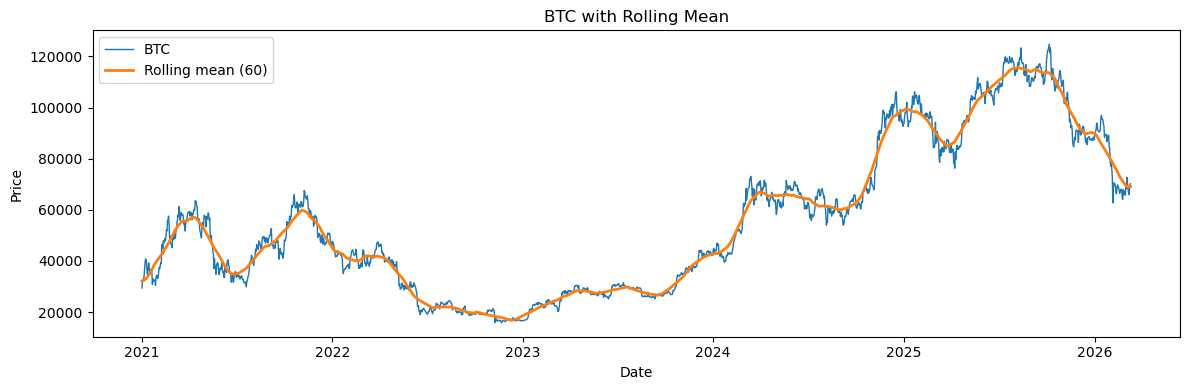

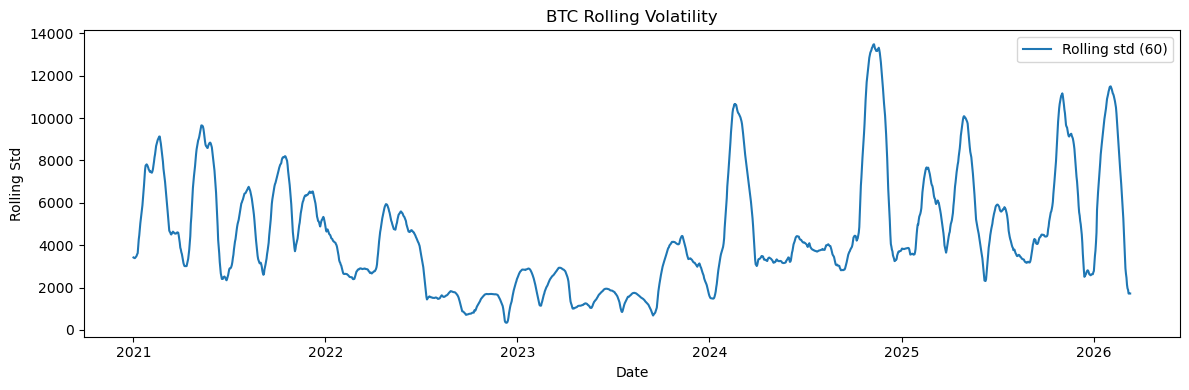

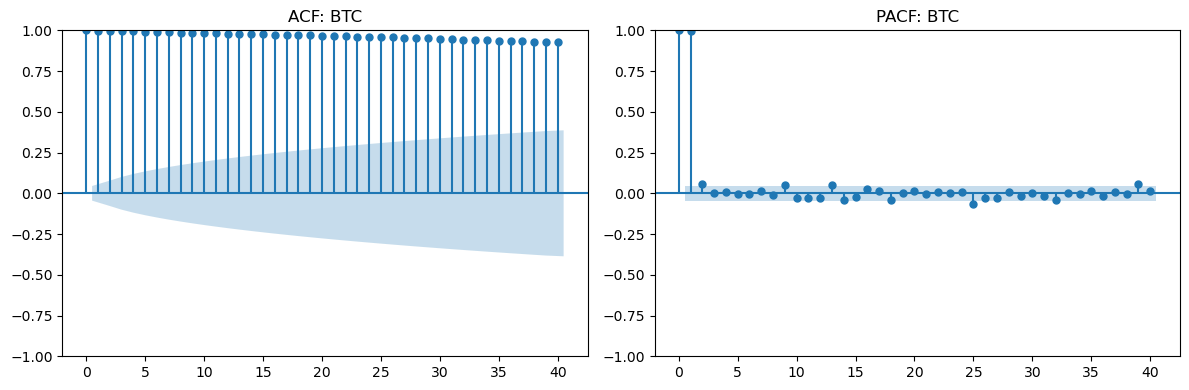

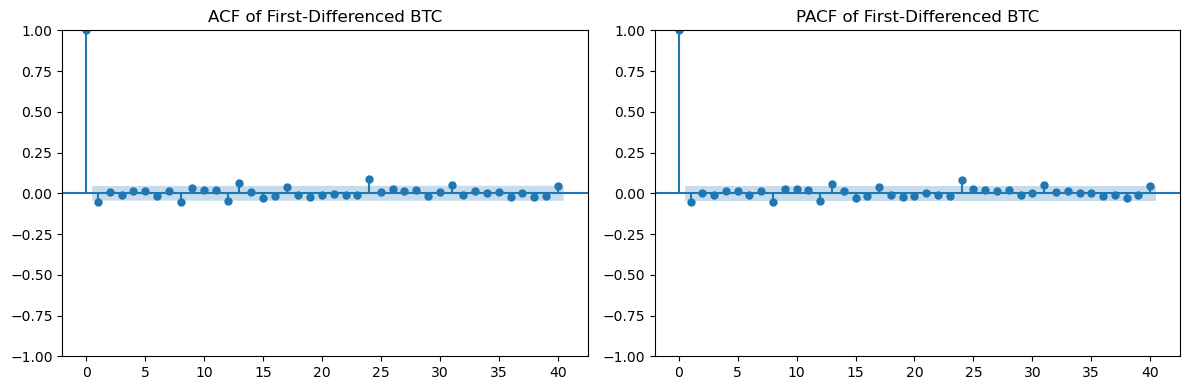

ADF on level:
{'stat': np.float64(-1.4177944113474696), 'pvalue': np.float64(0.5737161517849183)}
ADF on first difference:
{'stat': np.float64(-7.397055400010896), 'pvalue': np.float64(7.728588864654497e-11)}


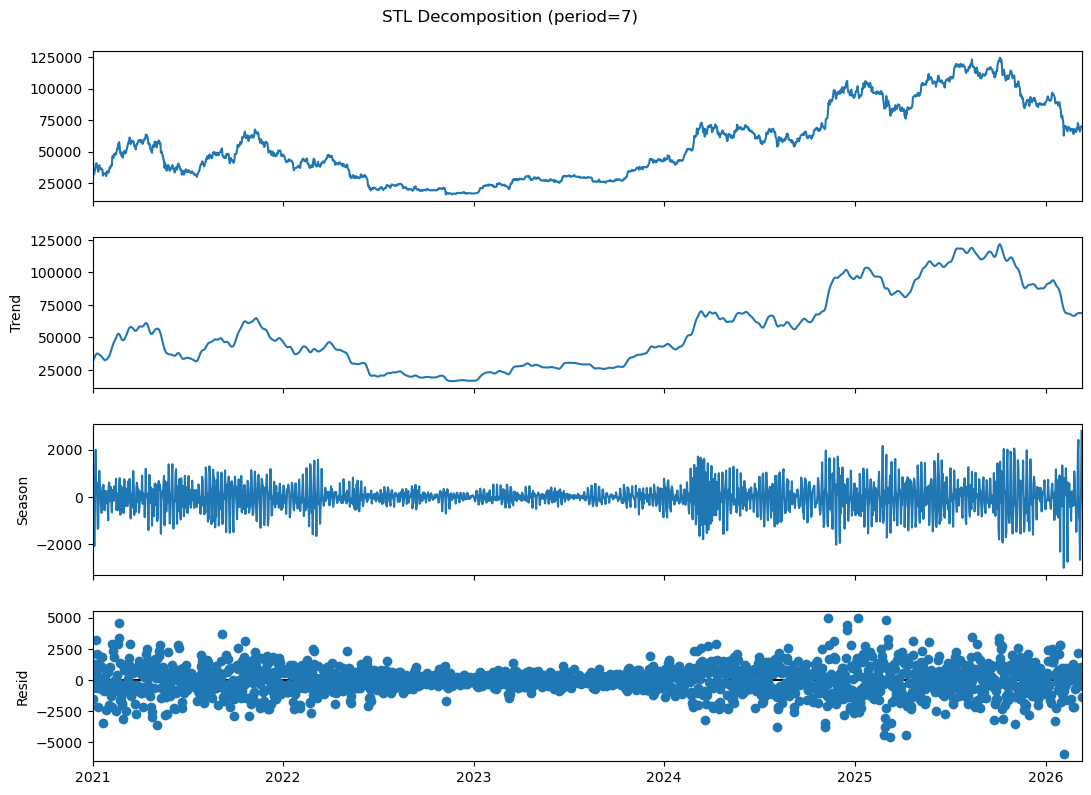

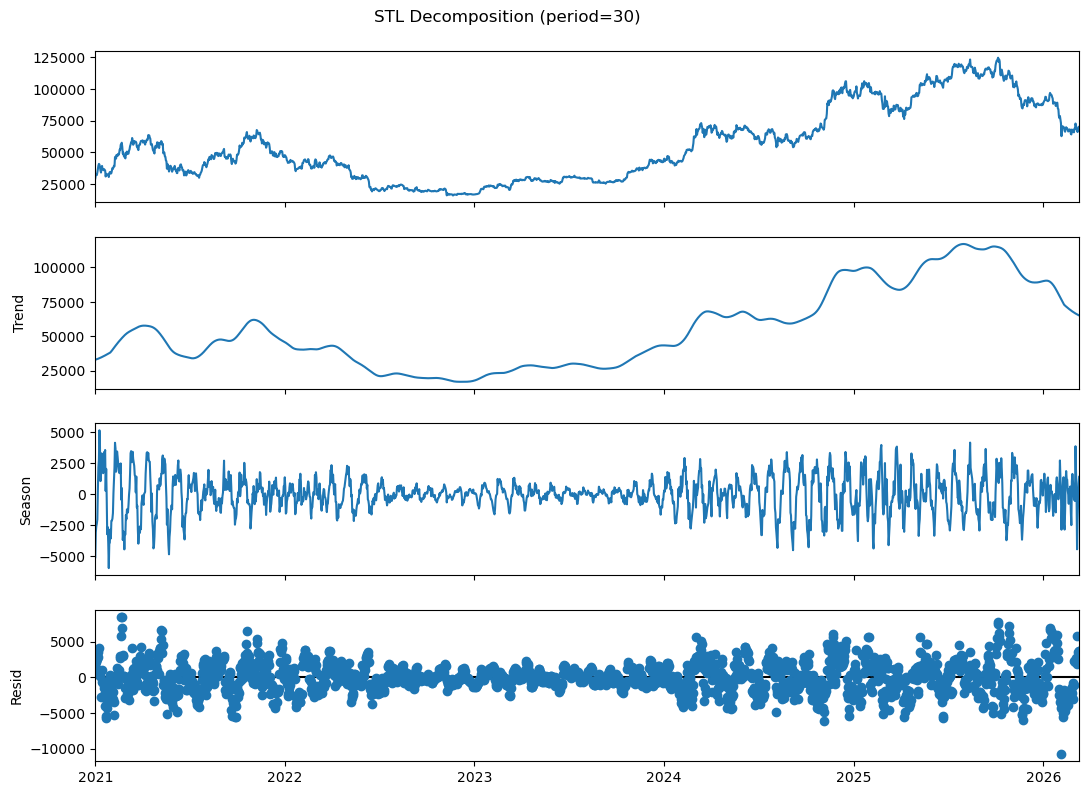

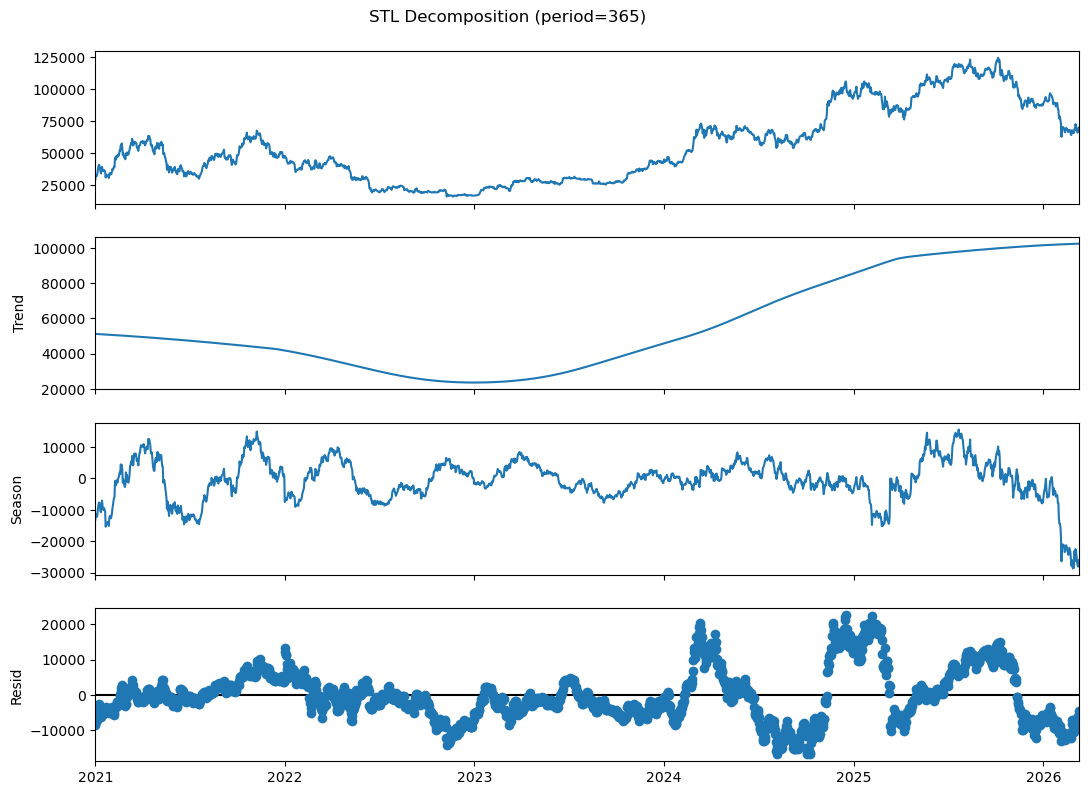

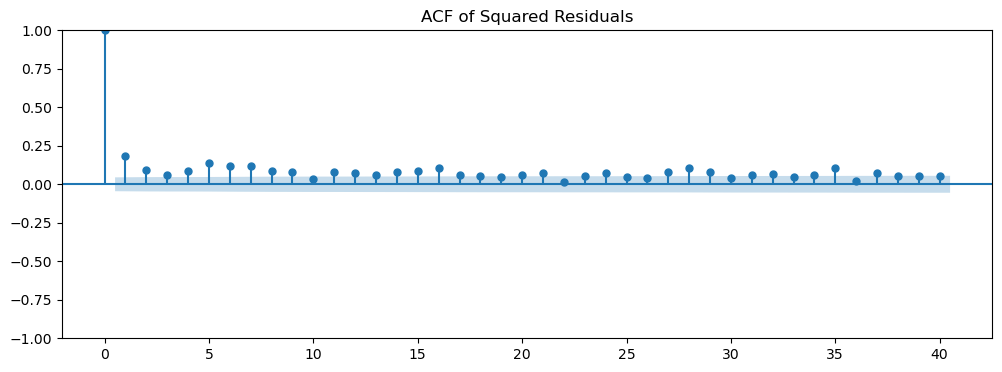


Ljung-Box Test:
      lb_stat  lb_pvalue
10  14.857571   0.137341
20  33.395704   0.030515
40  64.060224   0.009218


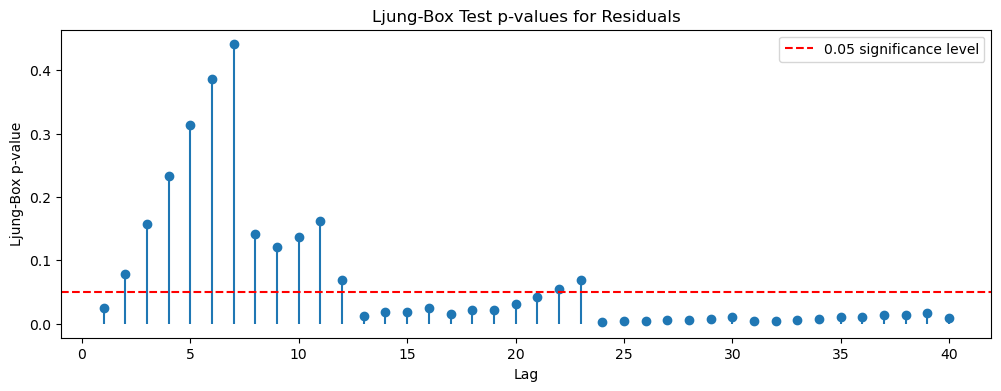

In [5]:
# plt.figure(figsize=(12, 6))
# plt.plot(df_orig, label=DATA_SET, linewidth=1)
# plt.title("BTC Closing Price")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend(ncol=3, fontsize=8)
# plt.tight_layout()
# plt.show()



plt.figure(figsize=(12, 6))
plt.plot(df, label=DATA_SET, linewidth=1)
plt.title("BTC Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()
window = 60
rmv = rolling_mean_vol(df, window=window)

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["value"], label=DATA_SET, linewidth=1)
plt.plot(rmv.index, rmv["roll_mean"], label=f"Rolling mean ({window})", linewidth=2)
plt.title("BTC with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["roll_std"], label=f"Rolling std ({window})", linewidth=1.5)
plt.title("BTC Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std")
plt.legend()
plt.tight_layout()
plt.show()

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df, lags=40, ax=axes[0])
plot_pacf(df, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF: BTC")
axes[1].set_title("PACF: BTC")
plt.tight_layout()
plt.show()

# ============================================================
# ACF / PACF of first difference
# ============================================================

dseries = df.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dseries, lags=40, ax=axes[0])
plot_pacf(dseries, lags=40, ax=axes[1], method="ywm")
axes[0].set_title(f"ACF of First-Differenced {DATA_SET}")
axes[1].set_title(f"PACF of First-Differenced {DATA_SET}")
plt.tight_layout()
plt.show()

adf_level = adfuller(df.dropna(), autolag=None)
adf_diff = adfuller(dseries, autolag=None)

print("ADF on level:")
print({"stat": adf_level[0], "pvalue": adf_level[1]})
print("ADF on first difference:")
print({"stat": adf_diff[0], "pvalue": adf_diff[1]})

# ============================================================
# STL Decomposition
# ============================================================
stl_results = {}
for p in [7, 30, 365]:
    stl = STL(df, period=p)
    res = stl.fit()
    stl_results[p] = {
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    }
    fig = res.plot()
    fig.set_size_inches(12,8)
    plt.suptitle(f"STL Decomposition (period={p})", y=1.02)
    plt.show()
    
# ============================================================
# ACF of squared residuals (volatility clustering)
# ============================================================

fig, ax = plt.subplots(1,1,figsize=(12,4))
plot_acf(dseries**2, lags=40, ax=ax)
ax.set_title("ACF of Squared Residuals")
plt.show()

# ============================================================
# Ljung-Box test for autocorrelation in residuals
# ============================================================


lb = acorr_ljungbox(dseries, lags=[10,20,40], return_df=True)
print("\nLjung-Box Test:")
print(lb)


lb_test = acorr_ljungbox(dseries, lags=40, return_df=True)
plt.figure(figsize=(12, 4))
plt.stem(lb_test.index, lb_test['lb_pvalue'], basefmt=" ")
plt.axhline(0.05, color='red', linestyle='--', label='0.05 significance level')
plt.xlabel("Lag")
plt.ylabel("Ljung-Box p-value")
plt.title("Ljung-Box Test p-values for Residuals")
plt.legend()
plt.show()

In [6]:
rows = []

for p, comp in stl_results.items():
    trend = comp["trend"]
    seasonal = comp["seasonal"]
    resid = comp["resid"]

    trend_var = np.var(trend)
    seasonal_var = np.var(seasonal)
    resid_var = np.var(resid)
    total_var = trend_var + seasonal_var + resid_var

    rows.append({
        "period": p,
        "trend_var": trend_var,
        "seasonal_var": seasonal_var,
        "resid_var": resid_var,
        "trend_share": trend_var / total_var,
        "seasonal_share": seasonal_var / total_var,
        "resid_share": resid_var / total_var
    })

decomp_summary = pd.DataFrame(rows)

print("\nSTL Decomposition Summary\n")
decomp_summary.round(4)


STL Decomposition Summary



,period,trend_var,seasonal_var,resid_var,trend_share,seasonal_share,resid_share
0,7,8.568910e+08,3.648322e+05,1.234934e+06,0.9981,0.0004,0.0014
1,30,8.444350e+08,1.954561e+06,4.460062e+06,0.9925,0.0023,0.0052
2,365,7.075470e+08,4.358467e+07,5.290821e+07,0.8800,0.0542,0.0658


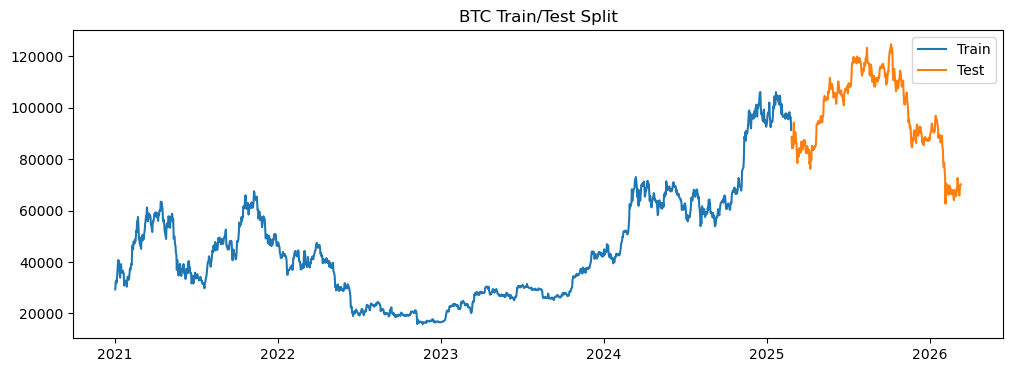

In [7]:
# ============================================================
# Train / Test Split
# ============================================================

train, test = train_test_split_ts(df, test_size=0.2)

plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title(f"{DATA_SET} Train/Test Split")
plt.legend()
plt.show()



In [8]:
# ============================================================
# Complete ARIMA Workflow
# ============================================================

def run_arima_pipeline(train, test, p_values=range(0,4), q_values=range(0,4)):
    d_selected, d_table = select_d_by_adf(train, max_d=2)

    results, best_order = arima_grid_search(
        train_series=train,
        p_values=p_values,
        d_values=[d_selected],
        q_values=q_values,
        criterion="aicc"
    )

    fit = fit_arima(train, best_order)
    forecast = forecast_model(fit, train, test)
    residual_diagnostics(fit)

    return fit, forecast

# ============================================================
# SARIMA Pipeline
# ============================================================

def run_sarima_pipeline(train, test, order=(1,1,1), seasonal_order=(1,0,1,7)):
    
    print("----- SARIMA MODEL -----")
    
    sarima_fit = fit_sarima(train, order, seasonal_order)
    
    forecast = forecast_model(sarima_fit, train, test)
    
    residual_diagnostics(sarima_fit)
    
    return sarima_fit, forecast

# ============================================================
# Rolling Forecast Evaluation
# ============================================================

def rolling_arima_forecast(series, order=(2,1,2), horizon=20, window=200):
    
    y_true = []
    y_pred = []
    
    for i in range(window, len(series)-horizon):
        
        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]
        
        model = ARIMA(train, order=order).fit()
        
        forecast = model.forecast(steps=horizon)
        
        y_true.append(test.values)
        y_pred.append(forecast.values)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return horizonwise_errors(y_true, y_pred)

# ============================================================
# Rolling forecast evaluation for SARIMA
# ============================================================

def rolling_sarima_forecast(series, order=(1,1,1), seasonal_order=(1,0,1,7), horizon=20, window=200):
    
    y_true = []
    y_pred = []
    
    for i in range(window, len(series) - horizon):
        
        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]
        
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        forecast = model.forecast(steps=horizon)
        
        y_true.append(test.values)
        y_pred.append(forecast.values)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return horizonwise_errors(y_true, y_pred)

# ============================================================
# ARIMA order selection by AICc
# ============================================================

def arima_grid_search(train_series, p_values, d_values, q_values, criterion="aic"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    fit = ARIMA(train_series, order=(p, d, q)).fit()
                    k = fit.params.shape[0]
                    n = len(train_series)
                    aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                    rows.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "aicc": aicc
                    })
                except Exception:
                    continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No ARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)
    best_order = tuple(results.loc[0, ["p", "d", "q"]].astype(int))

    return results, best_order

# ============================================================
# SARIMA order selection by AICc
# ============================================================

def sarima_grid_search(train_series,
                       p_values, d_values, q_values,
                       P_values, D_values, Q_values,
                       seasonal_period,
                       criterion="aicc"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            try:
                                fit = SARIMAX(
                                    train_series,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                k = fit.params.shape[0]
                                n = len(train_series)
                                aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                                rows.append({
                                    "p": p, "d": d, "q": q,
                                    "P": P, "D": D, "Q": Q,
                                    "s": seasonal_period,
                                    "aicc": aicc
                                })
                            except Exception:
                                continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No SARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)

    best = results.iloc[0]
    best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
    best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), int(best["s"]))

    return results, best_order, best_seasonal

# ============================================================
# Evaluate candidate ARIMA models on test data
# ============================================================

def evaluate_arima_candidates(train_series, test_series, candidates):
    rows = []

    for order in candidates:
        try:
            fit = ARIMA(train_series, order=order).fit()
            forecast = fit.forecast(steps=len(test_series))

            mse = mean_squared_error(test_series, forecast)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(test_series, forecast)
            bias = np.mean(forecast - test_series)

            rows.append({
                "order": order,
                "aic": fit.aic,
                "bic": fit.bic,
                "rmse": rmse,
                "mae": mae,
                "bias": bias
            })
        except Exception:
            continue

    results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return results

In [9]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.simplefilter("ignore", ConvergenceWarning)

Selected d = 1 based on ADF p-value = 0.0000
   d   adf_stat        pvalue
0  0  -0.539238  8.841294e-01
1  1 -10.268323  4.063545e-18
Top ARIMA candidates:
   p  d  q          aicc
0  3  1  2  26429.820018
1  0  1  0  26444.044567
2  1  1  0  26444.869306
3  0  1  1  26444.908284
4  1  1  1  26446.025997
5  2  1  0  26446.348279
6  0  1  2  26446.433571
7  2  1  1  26447.936035
8  3  1  0  26448.228096
9  0  1  3  26448.385247
Best ARIMA order: (3, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1516
Model:                 ARIMA(3, 1, 2)   Log Likelihood              -13208.882
Date:                Fri, 24 Apr 2026   AIC                          26429.764
Time:                        14:46:04   BIC                          26461.703
Sample:                    01-01-2021   HQIC                         26441.657
                         - 02-24-2025                             

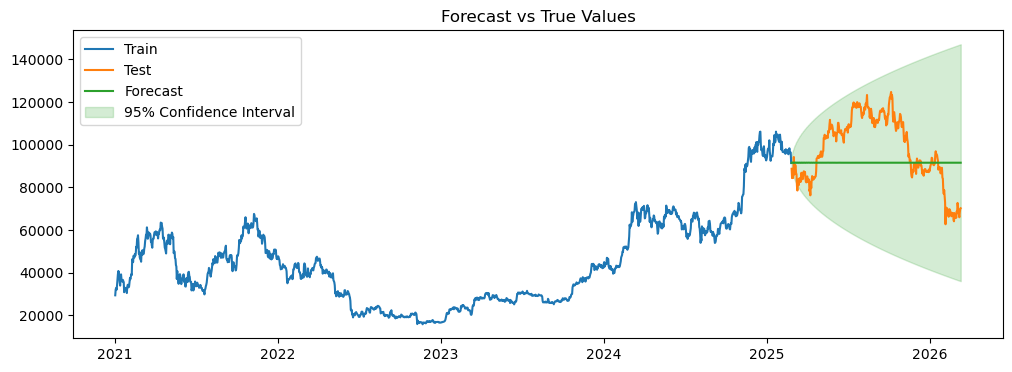

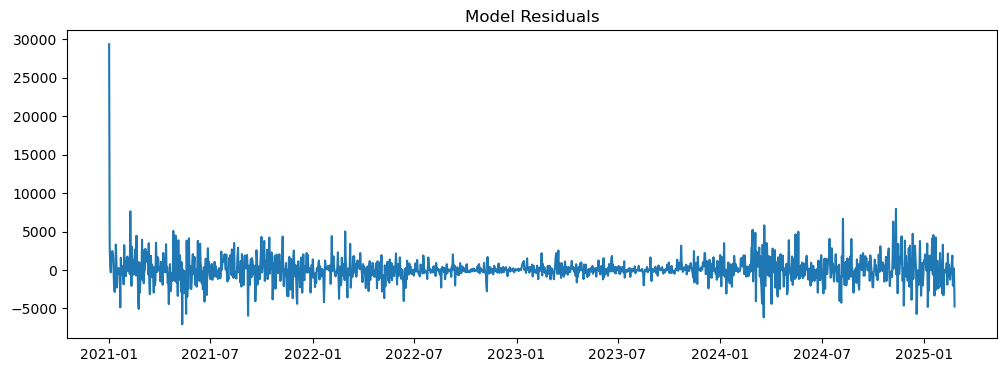

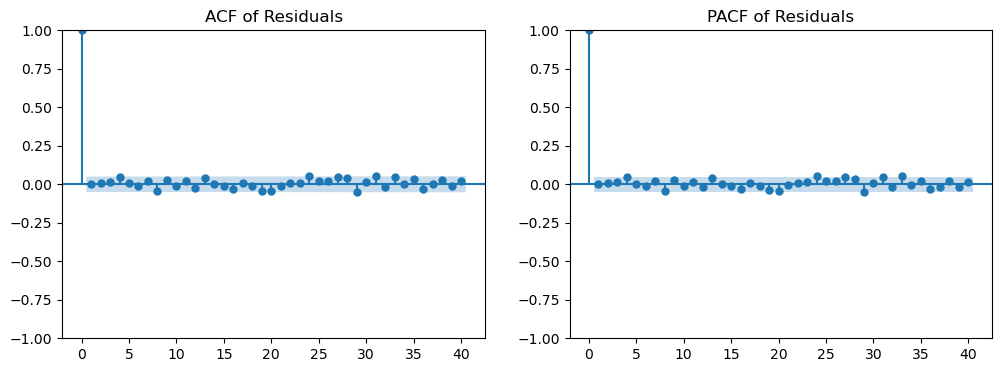


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10   9.358282   0.498472
20  20.470860   0.428843
40  49.489600   0.144502


In [10]:
# ============================================================
# ARIMA: choose d by ADF, then search (p,d,q), then fit best
# ============================================================

d_selected, d_table = select_d_by_adf(train, max_d=3, alpha=0.05)
print(d_table)

arima_results, best_arima_order = arima_grid_search(
    train_series=train,
    p_values=range(0, 4),
    d_values=[d_selected],
    q_values=range(0, 4),
    criterion="aicc"
)

print("Top ARIMA candidates:")
print(arima_results.head(10))
print("Best ARIMA order:", best_arima_order)

arima_fit = fit_arima(train, best_arima_order)
arima_forecast = forecast_model(arima_fit, train, test)
residual_diagnostics(arima_fit)

In [11]:
# ============================================================
# Top ARIMA candidates on test set
# ============================================================

top_arima_candidates = [
    tuple(arima_results.loc[i, ["p", "d", "q"]].astype(int))
    for i in range(min(5, len(arima_results)))
]

arima_test_compare = evaluate_arima_candidates(train, test, top_arima_candidates)

print("ARIMA candidates ranked by test RMSE:")
(arima_test_compare)

ARIMA candidates ranked by test RMSE:


,order,aic,bic,rmse,mae,bias
0,"(3, 1, 2)",26429.764352,26461.703376,16617.434307,13997.201226,-6220.445729
1,"(1, 1, 0)",26444.861375,26455.507716,16628.213039,14002.708880,-6249.174324
2,"(0, 1, 1)",26444.900353,26455.546695,16628.507721,14002.849618,-6249.970578
3,"(1, 1, 1)",26446.010124,26461.979636,16645.903772,14011.673316,-6296.026969
4,"(0, 1, 0)",26444.041925,26449.365096,16675.731112,14026.705557,-6374.548715


Top SARIMA candidates:
   p  d  q  P  D  Q  s          aicc
0  1  1  2  0  1  1  7  26236.025590
1  1  1  2  1  1  1  7  26237.690998
2  2  1  2  1  1  1  7  26239.490470
3  0  1  2  0  1  1  7  26244.248660
4  0  1  2  1  1  1  7  26246.127558
5  1  1  1  0  1  1  7  26256.656024
6  2  1  1  0  1  1  7  26257.456582
7  1  1  1  1  1  1  7  26258.532347
8  2  1  1  1  1  1  7  26259.447798
9  0  1  1  0  1  1  7  26260.138495
Best SARIMA order: (1, 1, 2)
Best seasonal order: (0, 1, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1516
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 7)   Log Likelihood              -13112.993
Date:                             Fri, 24 Apr 2026   AIC                          26235.986
Time:                                     14:46:38   BIC                          26262.545
Sample:                                 01-01-2

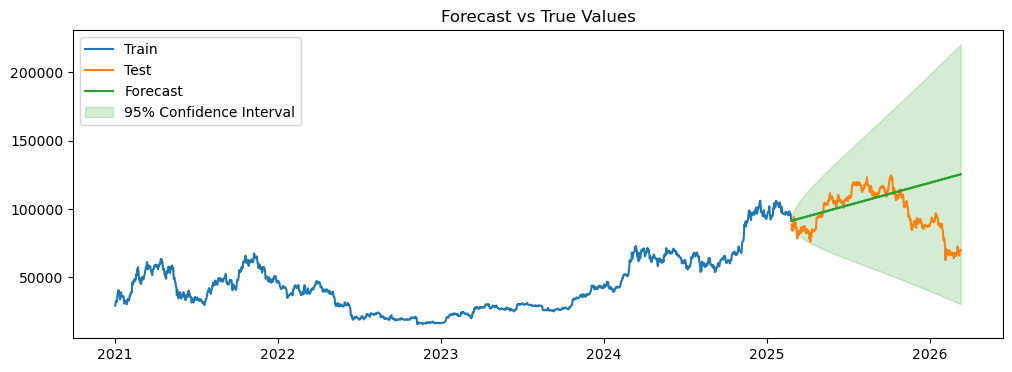

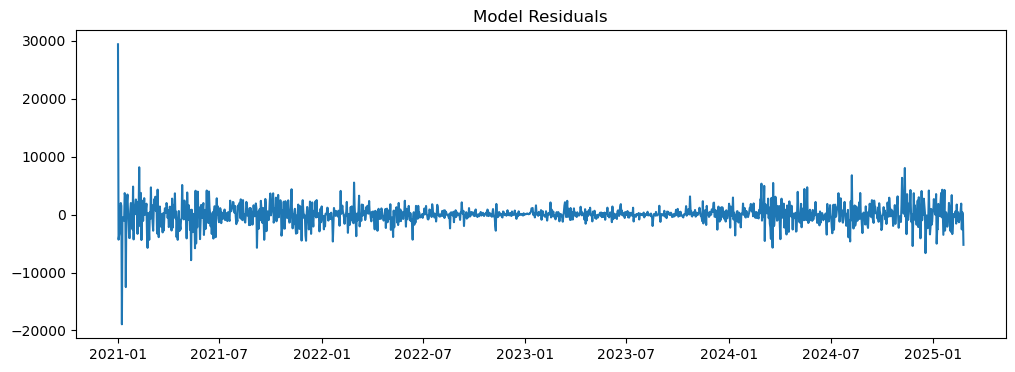

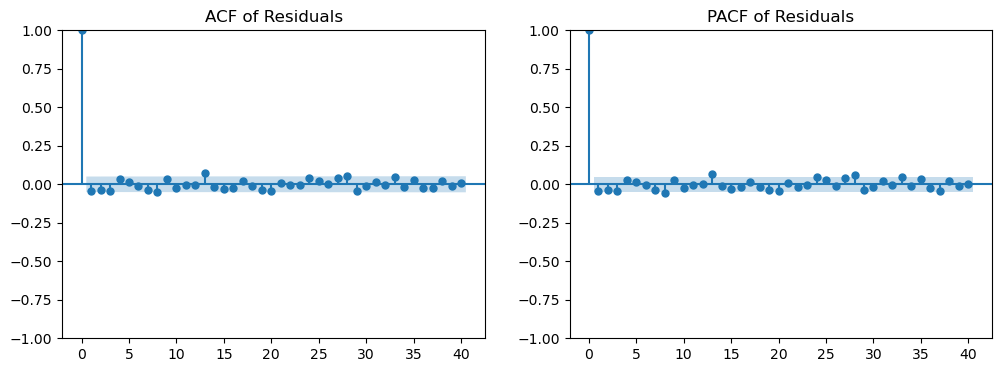


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10  18.600555   0.045640
20  35.890628   0.015843
40  57.740980   0.034322


In [12]:
# ============================================================
# SARIMA: only run if EDA suggests seasonality
# Try one seasonal period depending on dataset
# BTC -> 7
# SP500 -> maybe 5 or 7
# FRED -> maybe 5, 21, or skip if weak seasonality
# ============================================================

seasonal_period = 7   # change if needed

sarima_results, best_order, best_seasonal = sarima_grid_search(
    train_series=train,
    p_values=range(0, 3),
    d_values=[d_selected],
    q_values=range(0, 3),
    P_values=range(0, 2),
    D_values=[0, 1],
    Q_values=range(0, 2),
    seasonal_period=seasonal_period,
    criterion="aicc"
)

print("Top SARIMA candidates:")
print(sarima_results.head(10))
print("Best SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal)

sarima_fit = fit_sarima(train, best_order, best_seasonal)
sarima_forecast = forecast_model(sarima_fit, train, test)
residual_diagnostics(sarima_fit)

In [13]:
# ============================================================
# Top SARIMA candidates on test set
# ============================================================

top_sarima_candidates = [
    (
        tuple(sarima_results.loc[i, ["p", "d", "q"]].astype(int)),
        tuple(sarima_results.loc[i, ["P", "D", "Q", "s"]].astype(int))
    )
    for i in range(min(5, len(sarima_results)))
]

rows = []

for order, seasonal_order in top_sarima_candidates:
    try:
        fit = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast = fit.forecast(steps=len(test))

        mse = mean_squared_error(test, forecast)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(test, forecast)
        bias = np.mean(forecast - test)

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic,
            "rmse": rmse,
            "mae": mae,
            "bias": bias
        })
    except Exception:
        continue

sarima_test_compare = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

print("SARIMA candidates ranked by test RMSE:")
sarima_test_compare

SARIMA candidates ranked by test RMSE:


,order,seasonal_order,aic,bic,rmse,mae,bias
0,"(1, 1, 2)","(0, 1, 1, 7)",26235.985855,26262.545286,23076.628829,16532.437517,10675.847447
1,"(2, 1, 2)","(1, 1, 1, 7)",26239.416199,26276.599402,23321.066288,16637.968527,10950.941309
2,"(1, 1, 2)","(1, 1, 1, 7)",26237.635332,26269.506649,23380.712812,16662.823524,11036.964651
3,"(0, 1, 2)","(1, 1, 1, 7)",26246.087822,26272.647253,23600.382025,16753.151213,11363.604919
4,"(0, 1, 2)","(0, 1, 1, 7)",26244.222187,26265.469732,23626.012724,16763.247152,11421.036808


    horizon         bias     var_error          mae         rmse
0         1    64.824328  4.946765e+06  1582.680122  2225.076941
1         2   122.091512  9.171501e+06  2240.610307  3030.908708
2         3   170.789666  1.298098e+07  2749.035943  3606.958360
3         4   217.518471  1.683063e+07  3087.051008  4108.277021
4         5   269.426308  2.052438e+07  3431.276528  4538.388434
5         6   326.760701  2.442920e+07  3798.268804  4953.379640
6         7   403.693972  2.871499e+07  4139.592825  5373.821480
7         8   460.210753  3.324206e+07  4414.263715  5783.930469
8         9   519.292595  3.731344e+07  4748.019572  6130.505784
9        10   578.799862  4.097471e+07  5013.694387  6427.264046
10       11   642.727032  4.488165e+07  5218.914542  6730.137442
11       12   699.502712  4.893278e+07  5447.665729  7030.084296
12       13   753.652186  5.258222e+07  5595.128836  7290.418852
13       14   767.231077  5.662106e+07  5779.478481  7563.709642
14       15   785.811242 

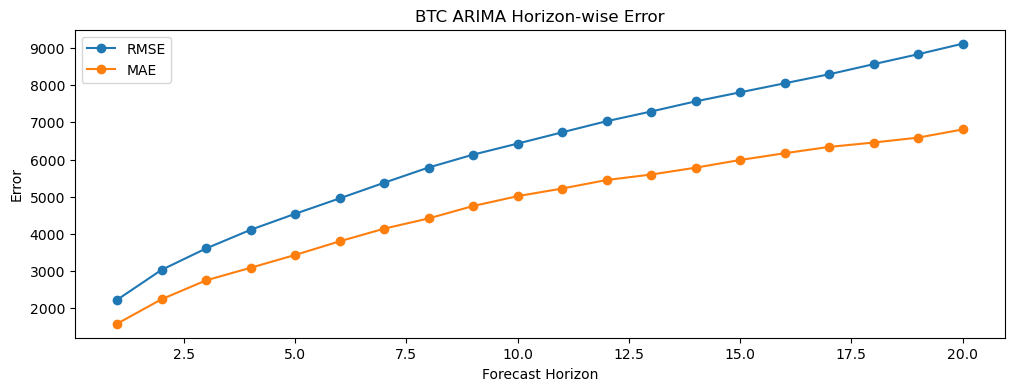

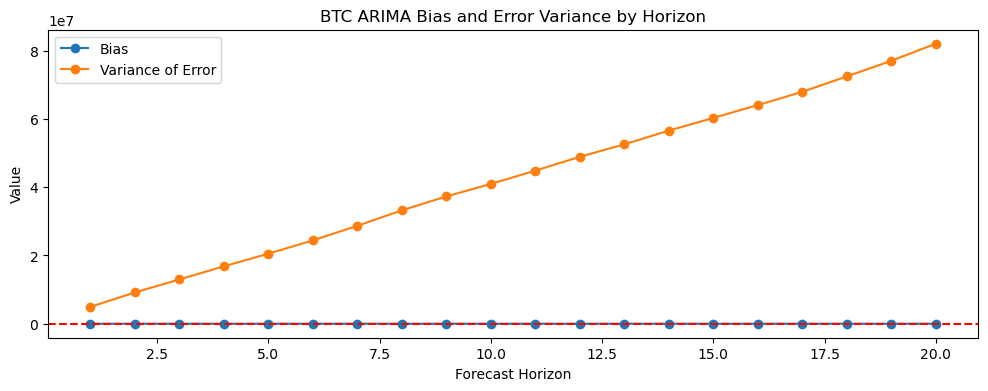

In [14]:
# ============================================================
# Rolling forecast evaluation for ARIMA
# ============================================================

rolling_arima_results = rolling_arima_forecast(
    series=df,
    order=best_arima_order,
    horizon=20,
    window=len(train)  
)

print(rolling_arima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["rmse"], marker="o", label="RMSE")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} ARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} ARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

    horizon         bias     var_error          mae         rmse
0         1   124.405242  4.921582e+06  1593.851997  2221.949311
1         2   236.748479  9.172723e+06  2266.331983  3037.889602
2         3   335.122192  1.307823e+07  2782.828834  3631.878479
3         4   442.087161  1.698730e+07  3128.398717  4145.206726
4         5   552.140358  2.056973e+07  3470.863579  4568.871605
5         6   668.981476  2.431062e+07  3827.523751  4975.756712
6         7   796.581726  2.864687e+07  4160.131940  5411.230199
7         8   902.863097  3.322450e+07  4453.571047  5834.351937
8         9  1017.799555  3.730660e+07  4788.448439  6192.133472
9        10  1139.228202  4.081786e+07  5071.801109  6489.661442
10       11  1265.262206  4.464069e+07  5291.715905  6800.116185
11       12  1372.937582  4.856320e+07  5474.878655  7102.686707
12       13  1476.879830  5.217537e+07  5625.480597  7372.688745
13       14  1555.765316  5.611074e+07  5867.950468  7650.565199
14       15  1629.887487 

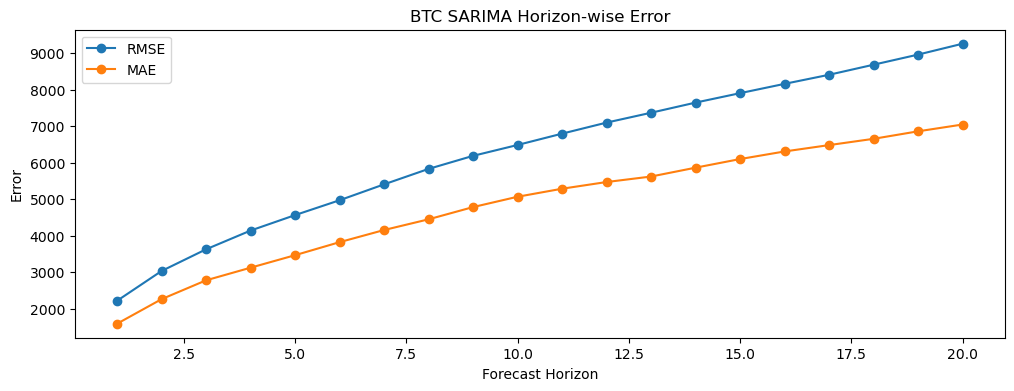

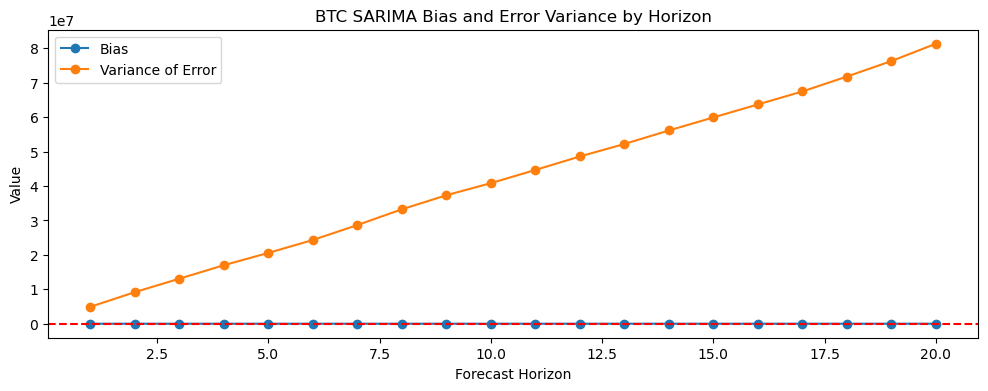

In [15]:
# ============================================================
# Rolling forecast evaluation for SARIMA
# ============================================================

rolling_sarima_results = rolling_sarima_forecast(
    series=df,
    order=best_order,
    seasonal_order=best_seasonal,
    horizon=20,
    window=len(train)
)

print(rolling_sarima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["rmse"], marker="o", label="RMSE")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} SARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} SARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

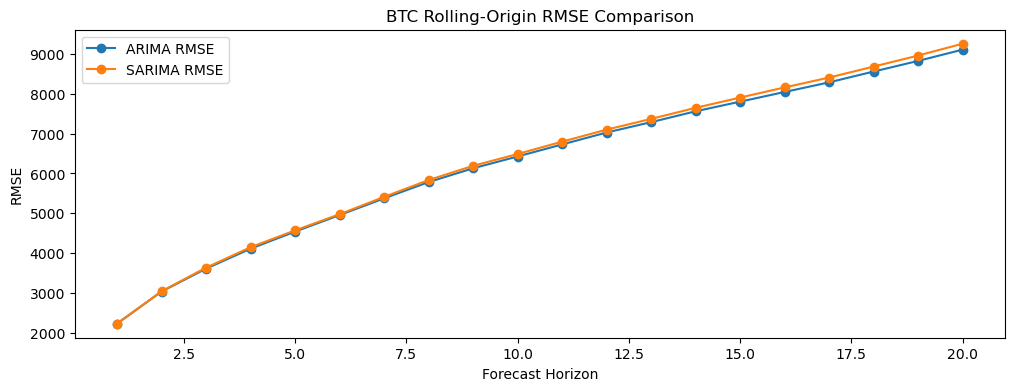

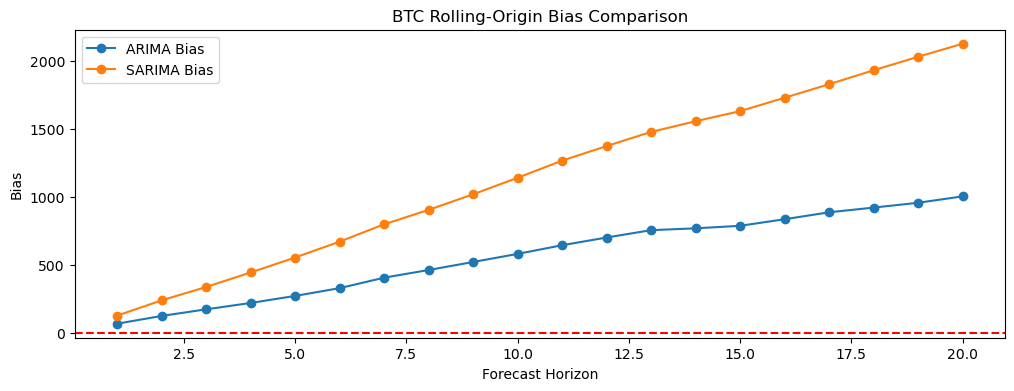

In [16]:
plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["rmse"], marker="o", label="ARIMA RMSE")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["rmse"], marker="o", label="SARIMA RMSE")
plt.title(f"{DATA_SET} Rolling-Origin RMSE Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="ARIMA Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="SARIMA Bias")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} Rolling-Origin Bias Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("Bias")
plt.legend()
plt.show()

In [17]:
# ============================================================
# Simple side-by-side final comparison
# ============================================================

final_compare = pd.DataFrame([
    accuracy_metrics(test, arima_forecast, label=f"ARIMA {best_arima_order}"),
    accuracy_metrics(test, sarima_forecast, label=f"SARIMA {best_order} x {best_seasonal}")
])

final_compare

ARIMA (3, 1, 2) MSE:   276139122.9378
ARIMA (3, 1, 2) RMSE:  16617.4343
ARIMA (3, 1, 2) MAE:   13997.2012
ARIMA (3, 1, 2) MAPE:  14.2886%
ARIMA (3, 1, 2) Bias:  -6220.4457
ARIMA (3, 1, 2) PM:    0.0282

SARIMA (1, 1, 2) x (0, 1, 1, 7) MSE:   532530798.0993
SARIMA (1, 1, 2) x (0, 1, 1, 7) RMSE:  23076.6288
SARIMA (1, 1, 2) x (0, 1, 1, 7) MAE:   16532.4375
SARIMA (1, 1, 2) x (0, 1, 1, 7) MAPE:  19.7501%
SARIMA (1, 1, 2) x (0, 1, 1, 7) Bias:  10675.8474
SARIMA (1, 1, 2) x (0, 1, 1, 7) PM:    0.0543



,Model,MSE,RMSE,MAE,MAPE,Bias,PM
0,"ARIMA (3, 1, 2)",2.761391e+08,16617.434307,13997.201226,14.288586,-6220.445729,0.028175
1,"SARIMA (1, 1, 2) x (0, 1, 1, 7)",5.325308e+08,23076.628829,16532.437517,19.750125,10675.847447,0.054335
